<h1>Zadanie 4</h1>

1. Načítajte z knižnice keras dátovú množinu fashion_mnist, ktorá obsahuje obrázky oblečenia klasifikovaných do 10 typov.
2. Vhodne predspracujte dáta.
3. Navrhnite a naučte vhodnú architektúru s konvolúčnými vrstvami. Pri učení zobrazte priebeh presnosti na trénovacích a testovacích dátach.
4. Otestujte výslednú naučenú sieť na testovacej množine a vypočítajte výslednú presnosť.

In [3]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

x train shape: (60000, 28, 28)
x test shape: (10000, 28, 28)


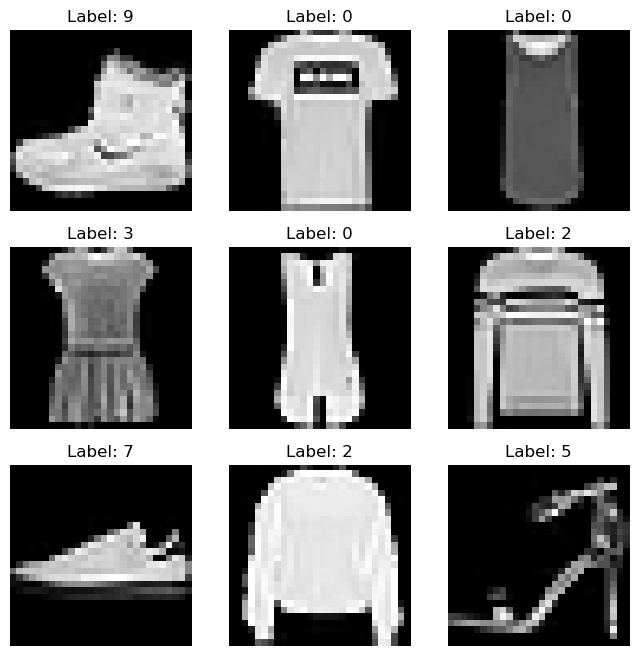

In [12]:
import matplotlib.pyplot as plt

print("x train shape:", x_train.shape)
print("x test shape:", x_test.shape)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


In [13]:
# počet obrázkov x šírka x výška x počet farebných kanálov
# čiernobiele obrázky = 1 farebný kanál
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

In [14]:
# 0 (čierna farba) po 255 (biela)
# norm 0-1
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

In [18]:
import numpy as np
len(np.unique(y_train))

10

In [20]:
from tensorflow.keras import utils
# cieľový kategorický atribút -> zakódovať ako binárny vektor
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1))) # 32 filtrov (sablon), okno 3x3, vstup:28x28x1 farebný kanál
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))# 32 filtrov (sablon), okno 3x3
model.add(MaxPooling2D(pool_size=(2,2))) # -2x pocet param: 28x28 -> 14x14
model.add(Dropout(0.25)) # -25% neuronov
model.add(Flatten()) # 2d -> 1d
model.add(Dense(128, activation='relu')) # dopredná sieť s jednou skrytou vrstvou - 128 neurónov
model.add(Dropout(0.5)) # -50% neuronov
model.add(Dense(10, activation='softmax')) # výstupná vrstva pre 10 tried

model.summary()

/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-19 11:21:16.228217: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 600,810 (2.29 MB)

 Trainable params: 600,810 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.optimizers import Adam

adam = Adam()
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

In [23]:
f = model.fit(x_train, y_train, epochs=3, batch_size=128, validation_data=(x_test, y_test))

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 364s 773ms/step - accuracy: 0.7994 - loss: 0.5596 - val_accuracy: 0.8679 - val_loss: 0.3673
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 342s 729ms/step - accuracy: 0.8677 - loss: 0.3665 - val_accuracy: 0.8922 - val_loss: 0.2952
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 341s 727ms/step - accuracy: 0.8869 - loss: 0.3127 - val_accuracy: 0.9001 - val_loss: 0.2725


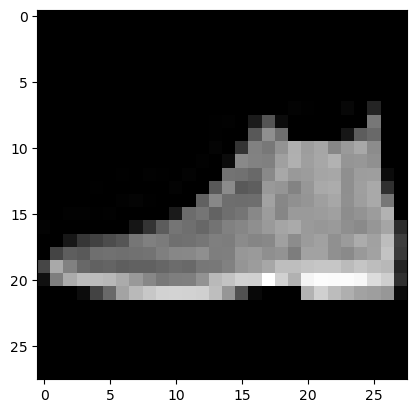

In [25]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
[9.0066726e-07 4.7149168e-08 1.0428507e-07 1.0822180e-06 5.1022138e-08
 5.1940669e-04 1.6348898e-07 1.0102592e-02 7.6841698e-06 9.8936802e-01]


([<matplotlib.axis.XTick at 0x74a6105de780>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

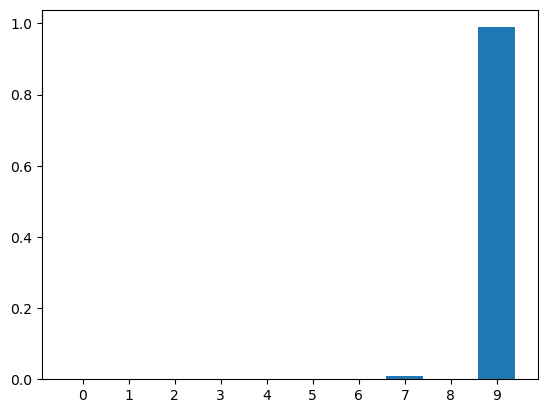

In [26]:
predictions = model.predict(x_test[:1])
print(predictions[0])
plt.bar(np.arange(10), predictions[0])
plt.xticks(np.arange(10))

In [29]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

In [30]:
test_loss

0.27246609330177307

In [31]:
test_accuracy

0.9000999927520752